# AnnDataProcessor
This notebook shows how to use the `AnnDataProcessor` component to interactive analyse {class}`anndata.AnnData` objects contained with {class}`spatialdata.SpatialData` objects.

The examples shown here follow on from the outputs of the [previous TMA processing section](tma_usage.ipynb).

In [1]:
# Below code loads napari to notebook for screenshot purposes
# All functions done on the viewer window3
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (20, 20)

from contextlib import redirect_stdout, redirect_stderr
import warnings
import io
from loguru import logger
warnings.filterwarnings("ignore")
logger.remove()

import napari
viewer = napari.current_viewer() or napari.Viewer()

2024-11-05 17:19:49.666 python[39684:12636231] +[CATransaction synchronize] called within transaction


Applying arcsinh transformation with cofactor: 150


## Starting fresh or continuing from TMAProcessor 
If starting fresh:
1. Import the SpatialData .zarr via napari-spatialdata (see [Getting started](getting_started.ipynb))
2. Select coordinate system to work with (global)
3. Select and double click the image element to add it as a layer (NSCLC4301)

If continuing directly from the [previous component](tma_usage.ipynb), simply launch the next widget (and optionally close or tab the TMAProcessor widget):

`Plugins` > `Tissue Microarray Processor` > `AnnDataProcessor`

Note that the widgets will expand due to the large width required to display plots in `AnnDataProcessor`

(-0.5, 1812.5, 934.5, -0.5)

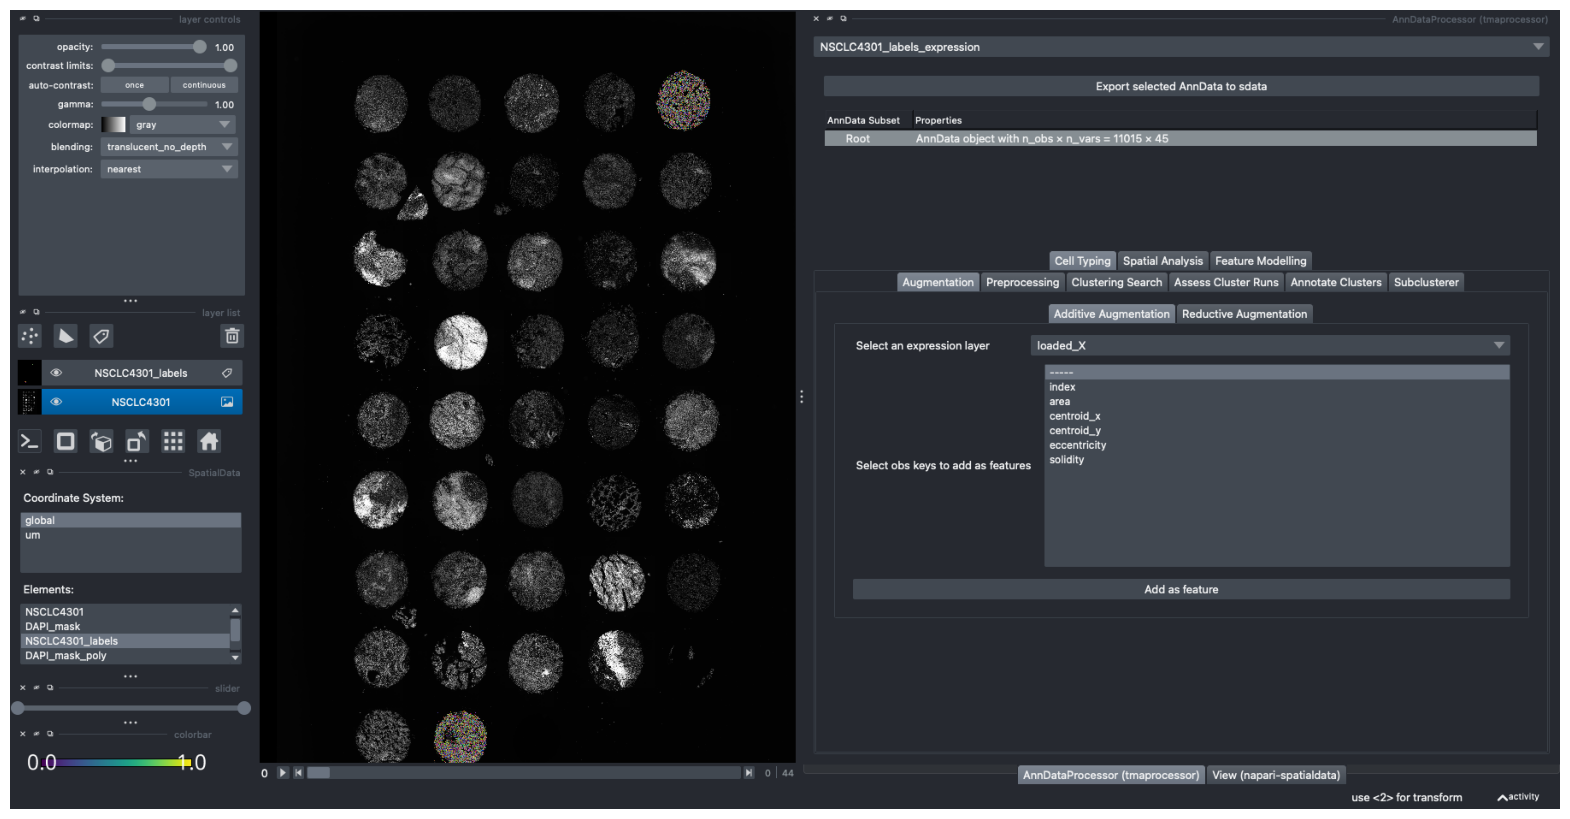

In [4]:
plt.imshow(viewer.screenshot(canvas_only=False))
plt.axis("off")

The `AnnDataProcessor` widget consists of various components arranged in a hierarchy. 

From top to bottom:
1. Table selection: This provides a list of tables in the SpatialData object from which the user can choose to analyse. In this case, the suitable table is the expression table.
2. Table save button: Unlike the previous component, this components allows for greater exploration on the AnnData structure, and as such, we provide a button to save the current results only when explicitly needed by the user. 
3. Subsetter widget: This is a display of a new data structure we introduce - a tree of AnnData copies and views. This is mainly for keeping track of parent-child relationships when subsetting AnnDatas in the analysis. The currently selected AnnData node is broadcasted globally to the analysis tabs.
4. Analysis tabs: These tabs (and their nested tabs) contains the widgets for performing majority of cell typing and basic spatial analysis. Feature modelling will be implemented in the future. Each tab widget holds a reference to the selected AnnData node, and so changes occur in-memory (for this reason, it is only possible to do one analysis step at a time).

## Augmentation Tab

This tab contains functions for adding or reducing the expression matrix.

### Additive Augmentation
Here the user can choose to expand along the expression matrix features by adding numerical {attr}`anndata.AnnData.obs` columns as {attr}`anndata.AnnData.var` attributes. For example, we can add morphological features like `solidity`, `eccentricity`, `area` as 'expression' features to aid in cell clustering downstream.

(-0.5, 1752.5, 934.5, -0.5)

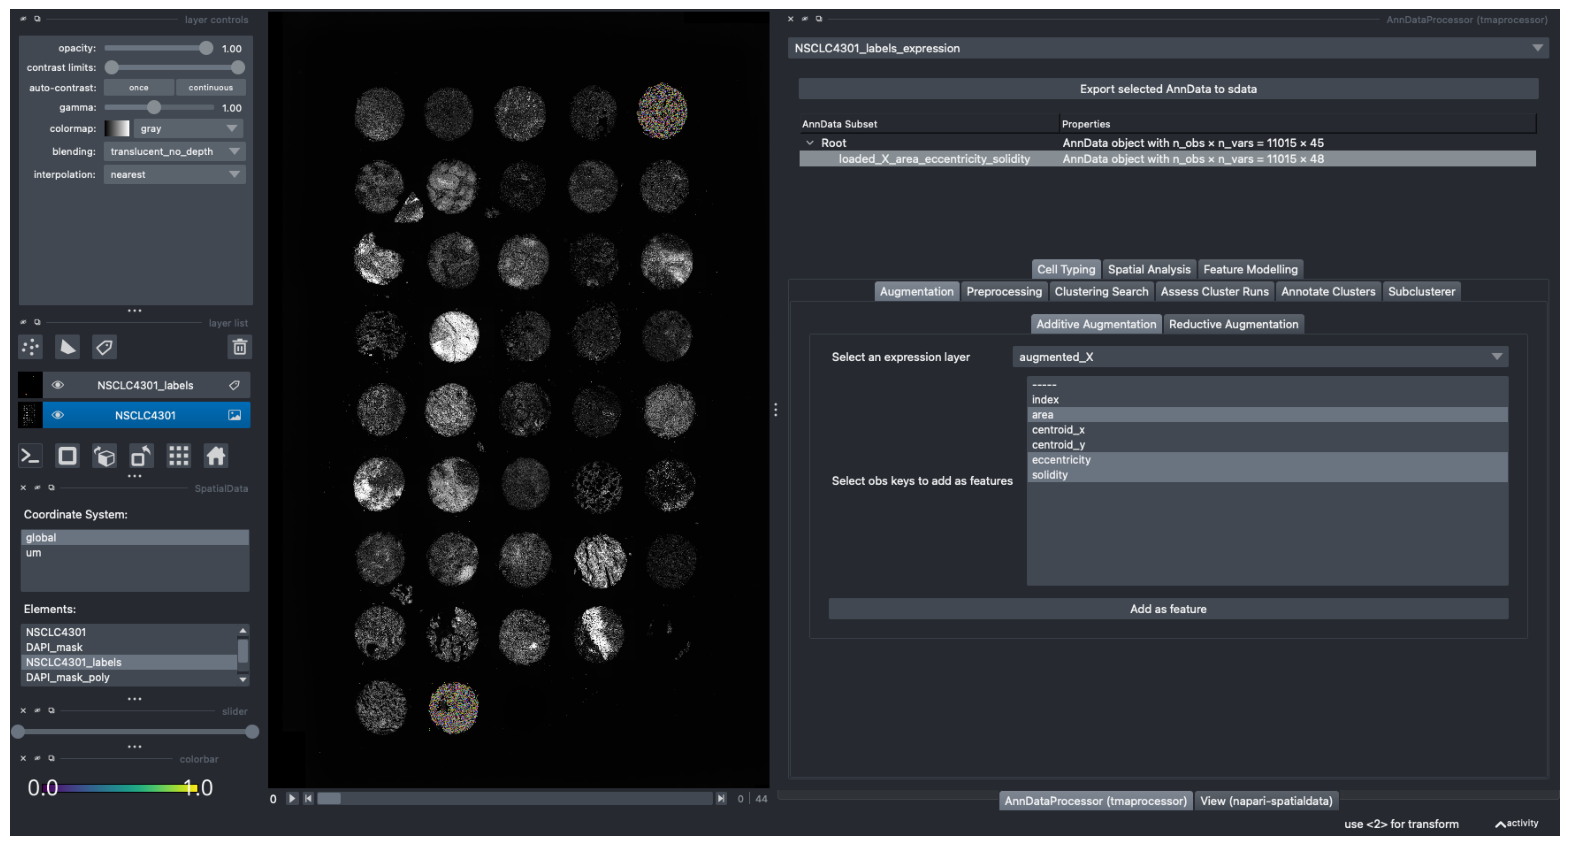

In [4]:
plt.imshow(viewer.screenshot(canvas_only=False))
plt.axis("off")

This adds a new AnnData 'subset' below the 'Root' AnnData object. We can then continue downstream analyses on this expanded AnnData containing morphological measurements by selecting it.

### Reductive Augmentation
Here the user can choose to reduce the expression matrix features (i.e. due to poor quality markers, or performing clustering on a subset of Tumour markers). In this example, we create two child subsets, one with the morphological features and E-cadherin, and another with E-cadherin alone. Note that these subsets are stored as 'Views' to conserve memory demands.

(-0.5, 1643.5, 934.5, -0.5)

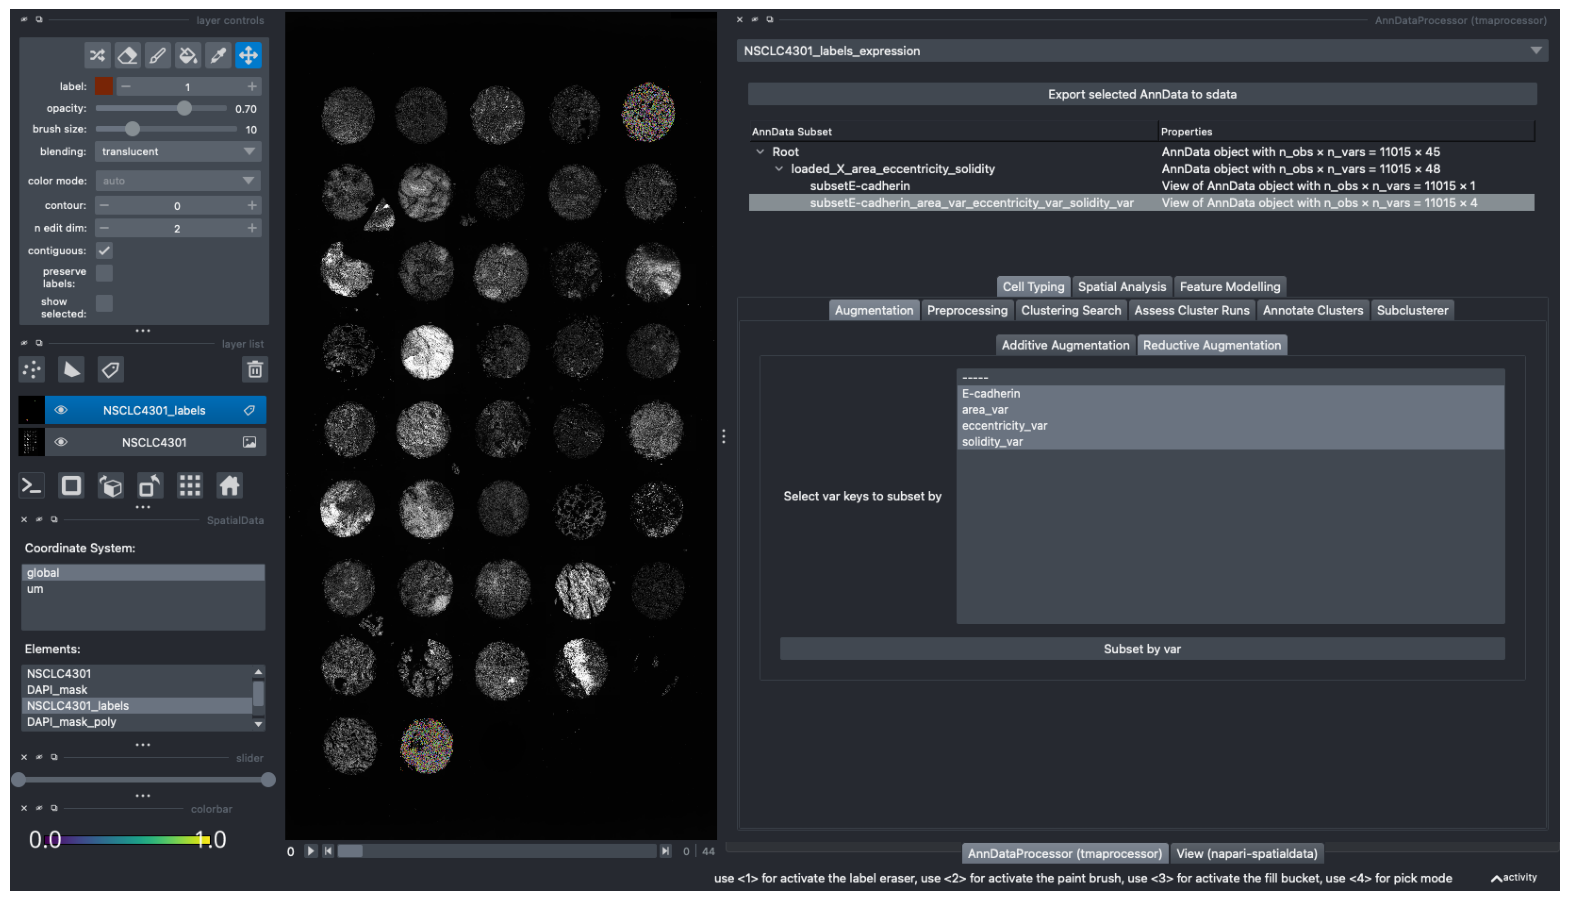

In [3]:
plt.imshow(viewer.screenshot(canvas_only=False))
plt.axis("off")

## Preprocessing Tab
This tab consists of three sub-tabs:
1. Transforms: Perform transformations sequentially on a user-specified expression layer.
2. Quality Control / Filtering: Interactive filtering with an integrated histogram plot to choose thresholds accordingly.
3. Dimensionality Reduction: Perform PCA, UMAP, and Harmonypy on a user-specified expression layer.

### Transforms
We provide 5 transform functions to choose from:
- Arcsinh (cofactor 150)
- Scale (wrapper for {func}`scanpy.pp.scale`)
- Percentile (95th)
- Z-score
- Log1p (log transform with pseudocount)

As an example, we perform 3 transforms in sequence: arcsinh, scale and then z-score. Once transform is called, a new expression layer will be added and available for selection:

(-0.5, 1766.5, 934.5, -0.5)

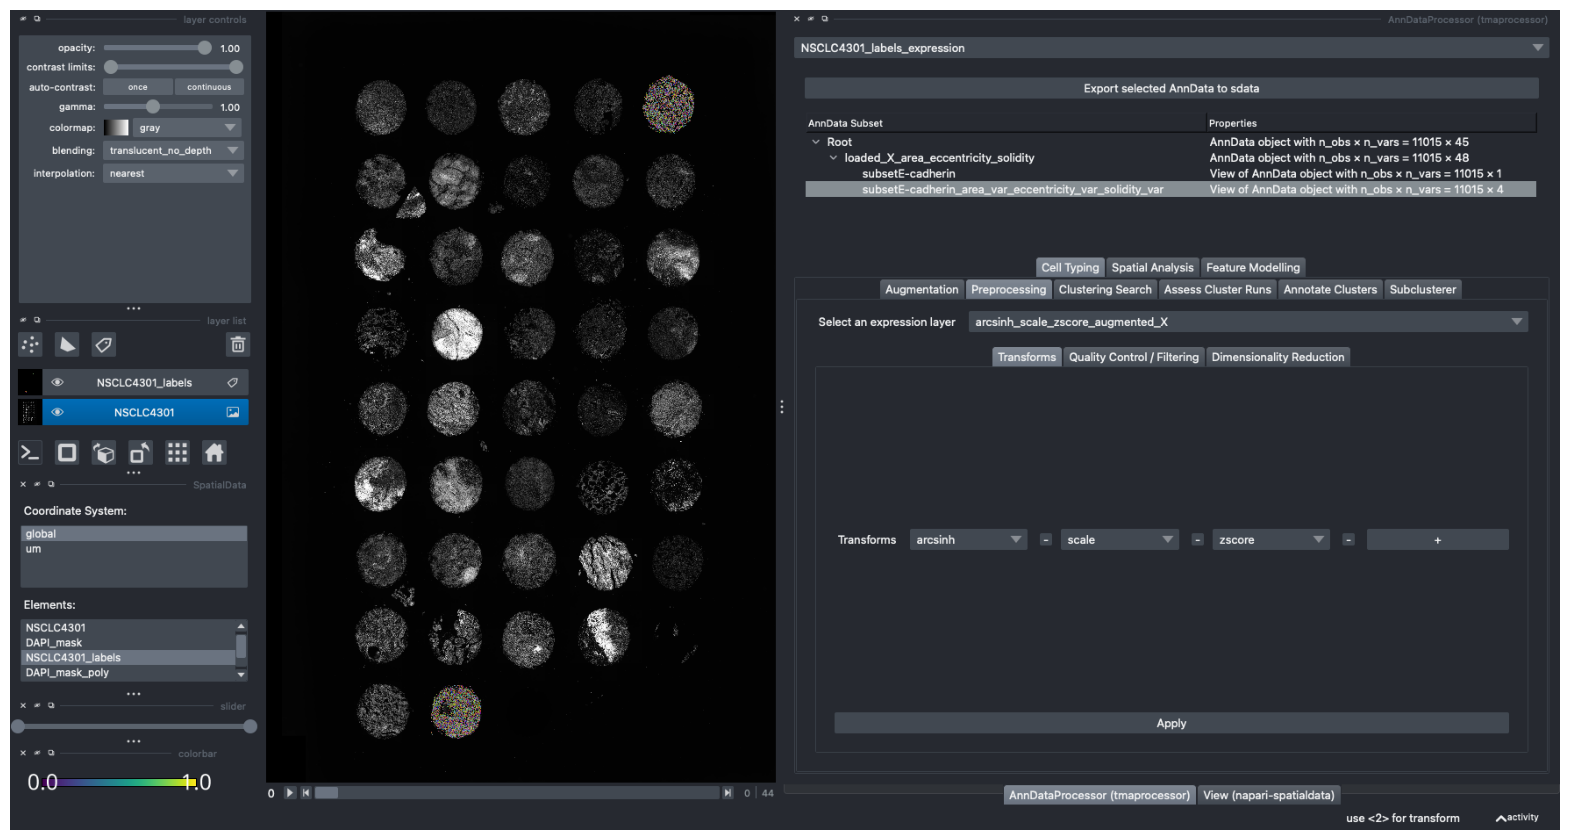

In [4]:
plt.imshow(viewer.screenshot(canvas_only=False))
plt.axis("off")

### Quality Control / Filtering

We provide 5 quality control functions to choose from:
- `filter_by_obs_count`: Filter out cells which belong to a categorical {attr}anndata.AnnData.obs value with less than X amount of cells. (i.e. filter out cells which belong to a TMA core with less than 50 cells)
  
- `filter_by_obs_value`: Filter out cells which have a numerical {attr}anndata.AnnData.obs value outside a user-defined range
  
- `filter_by_obs_percentile`: Same as filter_by_obs_value but using percentiles
  
- `filter_by_var_value`: Filter out cells which have values outside a user-defined range for the selected {attr}anndata.AnnData.var in the selected expression layer.
  
- `filter_by_var_quantile`: Same as filter_by_var_value but using percentiles

These will launch their own respective histogram plots, of which the user chooses a lower and upper bound, and the number of bins using sliders.

As an example, we use `filter_by_var_value` to filter out cells based on E-cadherin in the un-transformed layer (augmented_X), with 333 histogram bins. We then choose to filter out cells which have values (0.07) less than the first peak in the histogram:

(-0.5, 1649.5, 1010.5, -0.5)

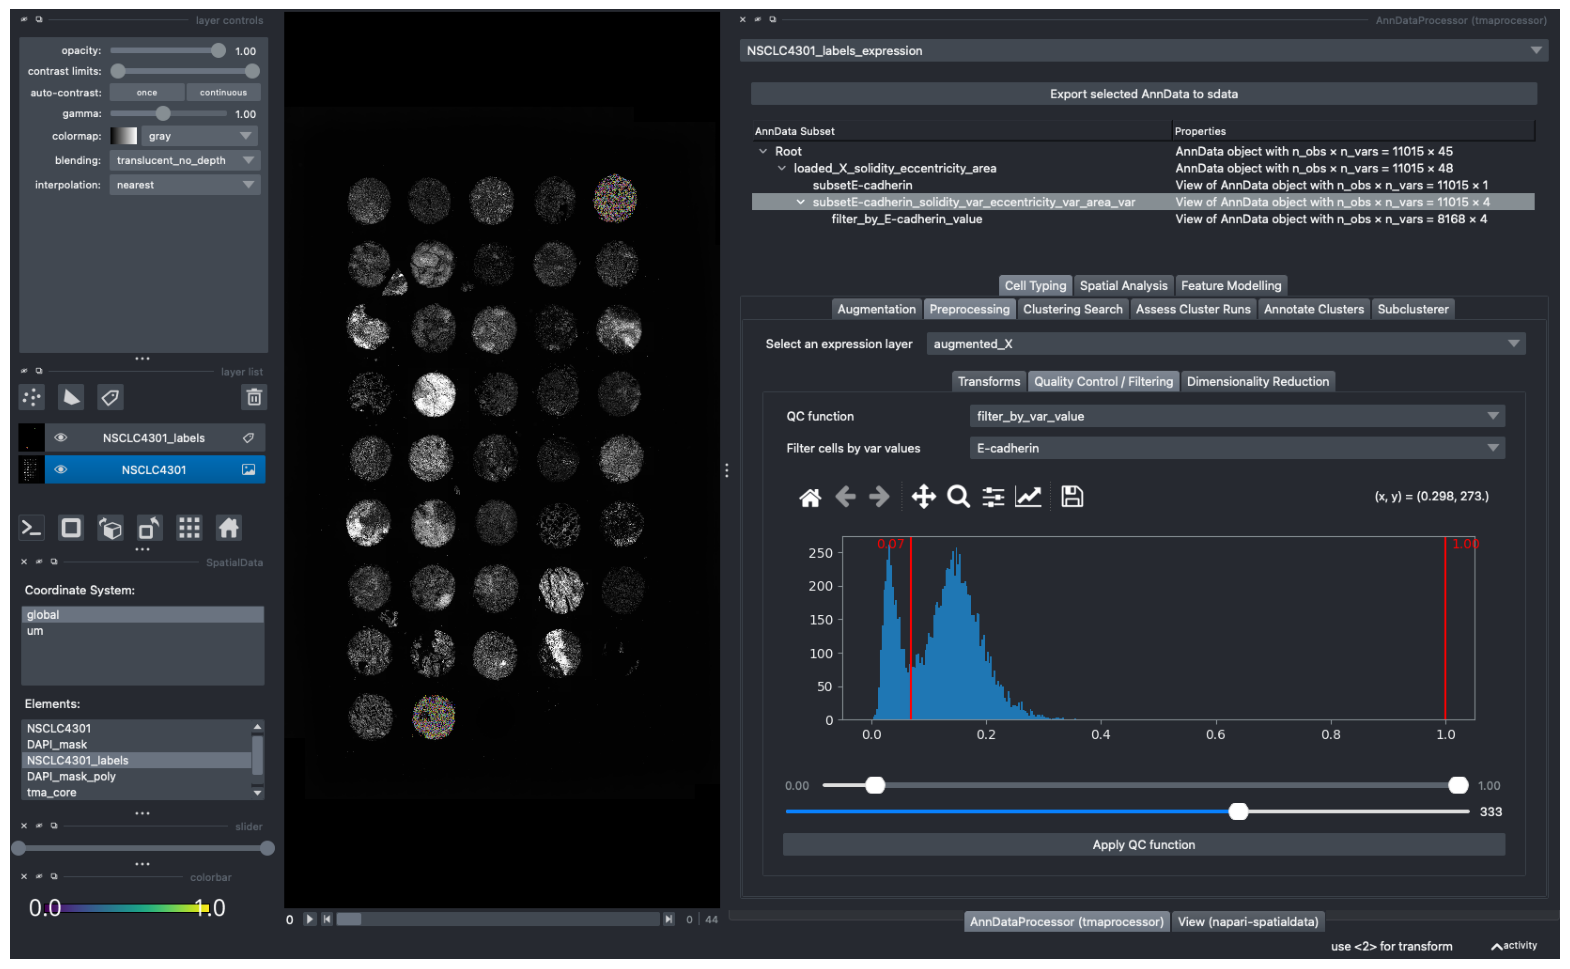

In [4]:
plt.imshow(viewer.screenshot(canvas_only=False))
plt.axis("off")

This produces a child AnnData subset 'View' containing only cells satisfying that filtering condition (named by the function and attribute used).

### Dimensionality Reduction